In [1]:
import torch
from PIL import Image
import requests
from transformers import AutoProcessor, Blip2ForImageTextRetrieval

device = "cuda" if torch.cuda.is_available() else "cpu"

model = Blip2ForImageTextRetrieval.from_pretrained("Salesforce/blip2-itm-vit-g", torch_dtype=torch.float16)
processor = AutoProcessor.from_pretrained("Salesforce/blip2-itm-vit-g")

model.to(device)
url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw)
text = "two cats laying on a pink blanket"

inputs = processor(images=image, text=text, return_tensors="pt").to(device, torch.float16)
with torch.cuda.amp.autocast():
    itm_out = model(**inputs, use_image_text_matching_head=True)
logits_per_image = torch.nn.functional.softmax(itm_out.logits_per_image, dim=1)
probs = logits_per_image.softmax(dim=1)  # we can take the softmax to get the label probabilities

print(f"{probs[0][0]:.1%} that image 0 is not '{text}'")

print(f"{probs[0][1]:.1%} that image 0 is '{text}'")

texts = ["a photo of a cat", "a photo of a dog"]

inputs = processor(images=image, text=texts, return_tensors="pt").to(device, torch.float16)
with torch.cuda.amp.autocast():
    itc_out = model(**inputs, use_image_text_matching_head=False)
logits_per_image = itc_out.logits_per_image  # this is the image-text similarity score
probs = logits_per_image.softmax(dim=1)  # we can take the softmax to get the label probabilities

print(f"{probs[0][0]:.1%} that image 0 is '{texts[0]}'")

print(f"{probs[0][1]:.1%} that image 0 is '{texts[1]}'")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Expanding inputs for image tokens in BLIP-2 should be done in processing. Please follow instruction here (https://gist.github.com/zucchini-nlp/e9f20b054fa322f84ac9311d9ab67042) to update your BLIP-2 model. Using processors without these attributes in the config is deprecated and will throw an error in v4.50.
/tmp/ipykernel_98161/2484006028.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


26.9% that image 0 is not 'two cats laying on a pink blanket'
73.0% that image 0 is 'two cats laying on a pink blanket'
55.3% that image 0 is 'a photo of a cat'
44.7% that image 0 is 'a photo of a dog'


/tmp/ipykernel_98161/2484006028.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Loading data from /home/maelic/Documents/Postdoc/OpenVocSGG/data/vg150_full.json...


Fetching 21 files:   0%|          | 0/21 [00:00<?, ?it/s]

Fetching 21 files:   0%|          | 0/21 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Number of mask channels: 1
Running inference with input_boxes: [[[453.515625, 259.375, 677.734375, 418.75], [322.65625, 268.75, 492.96875, 353.125]]]
torch.Size([2, 3, 600, 800])
tensor([[0.9861, 0.9832, 0.9812],
        [0.6605, 0.8649, 0.8738]], device='cuda:0')


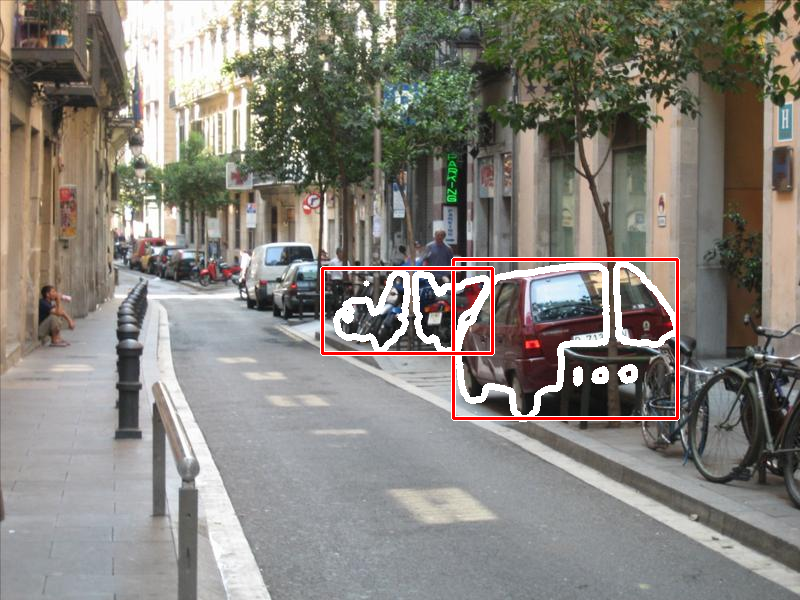

Description:
A red station wagon with a visible rear license plate, featuring a rear windshield wiper and a partially visible rear bumper.


In [1]:
# Copyright 2025 NVIDIA CORPORATION & AFFILIATES. All rights reserved.
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#     http://www.apache.org/licenses/LICENSE-2.0
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.
# SPDX-License-Identifier: Apache-2.0

import torch
import numpy as np
from PIL import Image
from transformers import SamModel, SamProcessor, AutoModel
import cv2
import requests
from io import BytesIO
from dataloader import RelDataset

def apply_sam(image, input_points=None, input_boxes=None, input_labels=None):
    inputs = sam_processor(image, input_points=input_points, input_boxes=input_boxes,
                           input_labels=input_labels, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = sam_model(**inputs)

    masks = sam_processor.image_processor.post_process_masks(
        outputs.pred_masks.cpu(),
        inputs["original_sizes"].cpu(),
        inputs["reshaped_input_sizes"].cpu()
    )[0]
    print(masks.shape)
    print(outputs.iou_scores[0])
    all_masks = []
    for i, m in enumerate(masks):
        scores = outputs.iou_scores[0, i]

        mask_selection_index = scores.argmax()
        mask_np = m[mask_selection_index].numpy()
        all_masks.append(mask_np)
    # combine all masks into a single mask
    if len(all_masks) > 1:
        all_masks = np.stack(all_masks, axis=0)
        all_masks = np.any(all_masks, axis=0).astype(np.float32)
    else:
        all_masks = all_masks[0]
    return all_masks


def add_contour(img, mask, input_points=None, input_boxes=None):
    img = img.copy()
    mask = mask.astype(np.uint8) * 255
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(img, contours, -1, (1.0, 1.0, 1.0), thickness=6)

    if input_points is not None:
        for points in input_points:
            for x, y in points:
                cv2.circle(img, (int(x), int(y)), radius=10, color=(1.0, 0.0, 0.0), thickness=-1)
                cv2.circle(img, (int(x), int(y)), radius=10, color=(1.0, 1.0, 1.0), thickness=2)

    if input_boxes is not None:
        for box_batch in input_boxes:
            for box in box_batch:
                x1, y1, x2, y2 = map(int, box)
                cv2.rectangle(img, (x1, y1), (x2, y2), color=(1.0, 1.0, 1.0), thickness=4)
                cv2.rectangle(img, (x1, y1), (x2, y2), color=(1.0, 0.0, 0.0), thickness=2)

    return img

def print_streaming(text):
    print(text, end="", flush=True)

if __name__ == '__main__':
    dataset_name = 'VG'
    dataset = RelDataset(dataset_name, max_samples=100, split='train', negative=False)

    img, img_cropped, img_visu, pair, boxes = dataset.get_random_pair(intersect=True, negative=False)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    sam_model = SamModel.from_pretrained("facebook/sam-vit-huge").to(device)
    sam_processor = SamProcessor.from_pretrained("facebook/sam-vit-huge")
    image_size = img.size  # (width, height)

    # Initialize DAM model once
    model = AutoModel.from_pretrained(
        'nvidia/DAM-3B-Self-Contained',
        trust_remote_code=True,
        torch_dtype='torch.float16'
    ).to(device)
    dam = model.init_dam(conv_mode='v1', prompt_mode='full+focal_crop')

    # Define two runs: one with points, one with box
    runs = [
        {
            'use_box': False,
            'points': [[1172, 812], [1572, 800]],
            'output_image_path': 'output_visualization_points.png'
        },
        {
            'use_box': True,
            'box': [800, 500, 1800, 1000],
            'output_image_path': 'output_visualization_box.png'
        }
    ]

    # Prepare box input
    input_boxes = [[boxes[0]['bbox'], boxes[1]['bbox']]] if boxes else None
    # convert boxes from x,y,w,h to x1,y1,x2,y2 format
    if input_boxes is not None:
        input_boxes = [[
            [box[0], box[1], box[0] + box[2], box[1] + box[3]] for box in input_boxes[0]
        ]]
    print(f"Running inference with input_boxes: {input_boxes}")
    mask_np = apply_sam(img, input_boxes=input_boxes)
    vis_points = None
    vis_boxes = input_boxes

    # Convert mask and describe
    mask = Image.fromarray((mask_np * 255).astype(np.uint8))
    # Save visualization with contour
    img_np = np.asarray(img).astype(float) / 255.0
    img_with_contour_np = add_contour(img_np, mask_np,
                                        input_points=vis_points,
                                        input_boxes=vis_boxes)
    img_with_contour_pil = Image.fromarray((img_with_contour_np * 255.0).astype(np.uint8))
    img_with_contour_pil.save('output_visualization_box.png')
    # print(f"Output image with contour saved as {run['output_image_path']}")
    display(img_with_contour_pil)

    print("Description:")
    for token in dam.get_description(
        img,
        mask,
        '<image>\nDescribe the relation between the two masked regions in detail.',
        streaming=True,
        temperature=0.2,
        top_p=0.5,
        num_beams=1,
        max_new_tokens=512
    ):
        print_streaming(token)
    print()  # newline